In [1]:
!pip install --upgrade yfinance

In [82]:
#Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score
from datetime import datetime
import yfinance as yf

In [106]:
#Grabbing Gold Stock Prices

gold = yf.Ticker("GC=F")
gold = gold.history(period = '20y')
gold

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2005-03-29 00:00:00-05:00,426.000000,426.000000,426.000000,426.000000,0,0.0,0.0
2005-03-31 00:00:00-05:00,428.700012,428.700012,428.700012,428.700012,3051,0.0,0.0
2005-04-01 00:00:00-05:00,428.299988,428.500000,424.500000,425.899994,552,0.0,0.0
2005-04-04 00:00:00-04:00,426.000000,426.299988,422.700012,423.899994,486,0.0,0.0
2005-04-05 00:00:00-04:00,423.799988,425.500000,423.600006,424.500000,313,0.0,0.0
...,...,...,...,...,...,...,...
2025-03-24 00:00:00-04:00,3024.300049,3024.300049,3006.000000,3013.100098,137,0.0,0.0
2025-03-25 00:00:00-04:00,3026.399902,3028.800049,3023.699951,3023.699951,74,0.0,0.0
2025-03-26 00:00:00-04:00,3033.199951,3033.199951,3019.500000,3020.899902,83,0.0,0.0


In [107]:
print(gold.columns)

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')


In [108]:
gold.index

DatetimeIndex(['2005-03-29 00:00:00-05:00', '2005-03-31 00:00:00-05:00',
               '2005-04-01 00:00:00-05:00', '2005-04-04 00:00:00-04:00',
               '2005-04-05 00:00:00-04:00', '2005-04-06 00:00:00-04:00',
               '2005-04-07 00:00:00-04:00', '2005-04-08 00:00:00-04:00',
               '2005-04-11 00:00:00-04:00', '2005-04-12 00:00:00-04:00',
               ...
               '2025-03-17 00:00:00-04:00', '2025-03-18 00:00:00-04:00',
               '2025-03-19 00:00:00-04:00', '2025-03-20 00:00:00-04:00',
               '2025-03-21 00:00:00-04:00', '2025-03-24 00:00:00-04:00',
               '2025-03-25 00:00:00-04:00', '2025-03-26 00:00:00-04:00',
               '2025-03-27 00:00:00-04:00', '2025-03-28 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=5028, freq=None)

In [109]:
gold.index = gold.index.date
gold

,Open,High,Low,Close,Volume,Dividends,Stock Splits
2005-03-29,426.000000,426.000000,426.000000,426.000000,0,0.0,0.0
2005-03-31,428.700012,428.700012,428.700012,428.700012,3051,0.0,0.0
2005-04-01,428.299988,428.500000,424.500000,425.899994,552,0.0,0.0
2005-04-04,426.000000,426.299988,422.700012,423.899994,486,0.0,0.0
2005-04-05,423.799988,425.500000,423.600006,424.500000,313,0.0,0.0
...,...,...,...,...,...,...,...
2025-03-24,3024.300049,3024.300049,3006.000000,3013.100098,137,0.0,0.0
2025-03-25,3026.399902,3028.800049,3023.699951,3023.699951,74,0.0,0.0
2025-03-26,3033.199951,3033.199951,3019.500000,3020.899902,83,0.0,0.0
2025-03-27,3025.500000,3065.000000,3025.500000,3060.199951,124359,0.0,0.0


<Axes: >

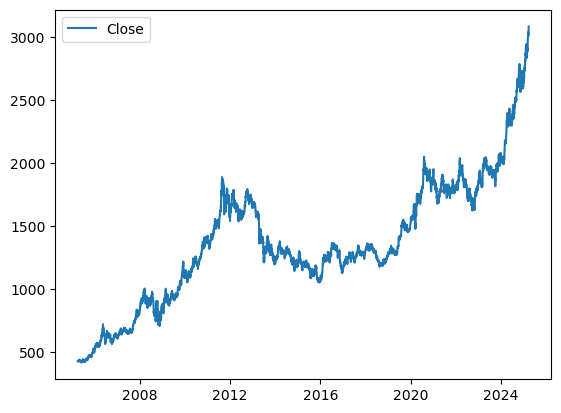

In [110]:
gold.plot.line(y = 'Close', use_index = True)

In [111]:
#Remove Columns not needed

del gold['Dividends']
del gold['Stock Splits']

In [112]:
#Creating a new column. Tomorrow's price values are 1 day infronts close price value.

gold['Tomorrow'] = gold['Close'].shift(-1)
gold

,Open,High,Low,Close,Volume,Tomorrow
2005-03-29,426.000000,426.000000,426.000000,426.000000,0,428.700012
2005-03-31,428.700012,428.700012,428.700012,428.700012,3051,425.899994
2005-04-01,428.299988,428.500000,424.500000,425.899994,552,423.899994
2005-04-04,426.000000,426.299988,422.700012,423.899994,486,424.500000
2005-04-05,423.799988,425.500000,423.600006,424.500000,313,427.100006
...,...,...,...,...,...,...
2025-03-24,3024.300049,3024.300049,3006.000000,3013.100098,137,3023.699951
2025-03-25,3026.399902,3028.800049,3023.699951,3023.699951,74,3020.899902
2025-03-26,3033.199951,3033.199951,3019.500000,3020.899902,83,3060.199951
2025-03-27,3025.500000,3065.000000,3025.500000,3060.199951,124359,3086.500000


In [113]:
#Checks if tomorrows price is greater then current days close (1 for true, 0 for false)

gold['Target'] = (gold['Tomorrow'] > gold['Close']).astype(int)
gold

,Open,High,Low,Close,Volume,Tomorrow,Target
2005-03-29,426.000000,426.000000,426.000000,426.000000,0,428.700012,1
2005-03-31,428.700012,428.700012,428.700012,428.700012,3051,425.899994,0
2005-04-01,428.299988,428.500000,424.500000,425.899994,552,423.899994,0
2005-04-04,426.000000,426.299988,422.700012,423.899994,486,424.500000,1
2005-04-05,423.799988,425.500000,423.600006,424.500000,313,427.100006,1
...,...,...,...,...,...,...,...
2025-03-24,3024.300049,3024.300049,3006.000000,3013.100098,137,3023.699951,1
2025-03-25,3026.399902,3028.800049,3023.699951,3023.699951,74,3020.899902,0
2025-03-26,3033.199951,3033.199951,3019.500000,3020.899902,83,3060.199951,1
2025-03-27,3025.500000,3065.000000,3025.500000,3060.199951,124359,3086.500000,1


In [114]:
#Starting to trian first model

model = RandomForestClassifier(n_estimators = 100, min_samples_split = 100, random_state = 1)

train = gold.iloc[:-100]
test = gold.iloc[-100:]

predictors = ['Close', 'Volume', 'Open', 'High', 'Low']
model.fit(train[predictors], train['Target'])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [115]:
preds = model.predict(test[predictors])
preds = pd.Series(preds, index = test.index)

precision_score(test['Target'], preds)

0.5918367346938775

<Axes: >

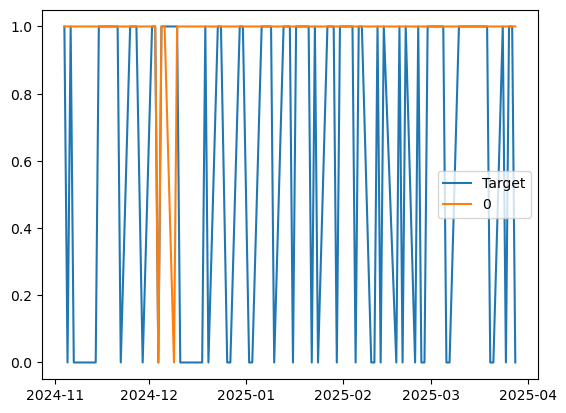

In [116]:
#Plot the predicitons

combined = pd.concat([test['Target'], preds], axis = 1)

combined.plot()

In [117]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train['Target'])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index = test.index, name = 'Predictions')
    combined = pd.concat([test['Target'], preds], axis = 1)
    return combined

In [137]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []
    
    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i]
        test = data.iloc[i:(i+step)]
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [119]:
predictions = backtest(gold, model, predictors)

In [120]:
#Shows how many days we predicted market would go up (1) or down (0)

predictions['Predictions'].value_counts()

Predictions
1    1313
0    1215
Name: count, dtype: int64

In [121]:
#The percent we said that the market would go up, in this case 54.7% of the time

precision_score(predictions['Target'], predictions['Predictions'])

0.511043412033511

In [122]:
#The percent of days the market actually went up, actual values. 54.9%

predictions['Target'].value_counts() / predictions.shape[0]

Target
1    0.527294
0    0.472706
Name: count, dtype: float64

In [123]:
#Adding more predictors to see if this imporves accuracy. 2 = 2 days, 5 = trading week, 60 = trading month, 250 = year, 1000 = 4 years

horizons = [2, 5, 60, 250, 1000]
new_predictors = []

for horizon in horizons:
    rolling_average = gold.rolling(horizon).mean()
    
    ratio_column = f'Close_Ratio_{horizon}'
    gold[ratio_column] = gold['Close'] / rolling_average['Close']
    
    trend_column = f'Trend_{horizon}'
    gold[trend_column] = gold.shift(1).rolling(horizon).sum()['Target']
    
    new_predictors += [ratio_column, trend_column] 

In [124]:
gold

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
2005-03-29,426.000000,426.000000,426.000000,426.000000,0,428.700012,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-03-31,428.700012,428.700012,428.700012,428.700012,3051,425.899994,0,1.003159,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-04-01,428.299988,428.500000,424.500000,425.899994,552,423.899994,0,0.996724,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-04-04,426.000000,426.299988,422.700012,423.899994,486,424.500000,1,0.997647,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-04-05,423.799988,425.500000,423.600006,424.500000,313,427.100006,1,1.000707,1.0,0.996947,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-24,3024.300049,3024.300049,3006.000000,3013.100098,137,3023.699951,1,0.999154,0.0,0.994928,3.0,1.062704,38.0,1.173029,149.0,1.474741,547.0
2025-03-25,3026.399902,3028.800049,3023.699951,3023.699951,74,3020.899902,0,1.001756,1.0,0.999180,3.0,1.064035,38.0,1.175603,149.0,1.478990,547.0
2025-03-26,3033.199951,3033.199951,3019.500000,3020.899902,83,3060.199951,1,0.999537,1.0,0.999246,2.0,1.060539,38.0,1.173000,148.0,1.476686,546.0
2025-03-27,3025.500000,3065.000000,3025.500000,3060.199951,124359,3086.500000,1,1.006463,1.0,1.010894,2.0,1.071489,39.0,1.186707,148.0,1.494933,546.0


In [125]:
gold = gold.dropna()
gold

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
2009-03-24,923.299988,923.299988,923.299988,923.299988,1494,935.400024,1,0.984643,0.0,0.986811,1.0,1.019236,28.0,1.065769,118.0,1.351639,523.0
2009-03-25,921.200012,936.500000,920.799988,935.400024,97,939.599976,1,1.006510,1.0,0.989862,2.0,1.031359,28.0,1.079712,119.0,1.368337,523.0
2009-03-26,939.599976,943.000000,937.599976,939.599976,66,923.000000,0,1.002240,2.0,0.998258,2.0,1.034754,28.0,1.084443,120.0,1.373449,524.0
2009-03-27,923.000000,923.000000,923.000000,923.000000,106869,915.500000,0,0.991088,1.0,0.987504,2.0,1.015472,28.0,1.065087,120.0,1.348201,524.0
2009-03-30,924.599976,932.500000,908.599976,915.500000,58837,922.599976,1,0.995921,0.0,0.987211,2.0,1.006632,27.0,1.056333,119.0,1.336287,523.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-21,3034.500000,3037.500000,3000.899902,3018.199951,151,3013.100098,0,0.996402,1.0,0.997475,4.0,1.066968,39.0,1.176551,150.0,1.478177,548.0
2025-03-24,3024.300049,3024.300049,3006.000000,3013.100098,137,3023.699951,1,0.999154,0.0,0.994928,3.0,1.062704,38.0,1.173029,149.0,1.474741,547.0
2025-03-25,3026.399902,3028.800049,3023.699951,3023.699951,74,3020.899902,0,1.001756,1.0,0.999180,3.0,1.064035,38.0,1.175603,149.0,1.478990,547.0
2025-03-26,3033.199951,3033.199951,3019.500000,3020.899902,83,3060.199951,1,0.999537,1.0,0.999246,2.0,1.060539,38.0,1.173000,148.0,1.476686,546.0


In [138]:
model = RandomForestClassifier(n_estimators = 200, min_samples_split = 50, random_state = 1)

def predict(train, test, predictors, model):
    model.fit(train[predictors], train['Target'])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >= .6] = 1
    preds[preds < .6] = 0
    preds = pd.Series(preds, index = test.index, name = 'Predictions')
    combined = pd.concat([test['Target'], preds], axis = 1)
    return combined

In [139]:
predictions = backtest(gold, model, new_predictors)

In [140]:
predictions['Predictions'].value_counts()

Predictions
0.0    1333
1.0     194
Name: count, dtype: int64

In [141]:
precision_score(predictions['Target'], predictions['Predictions'])

0.5670103092783505

In [143]:
predictions

,Target,Predictions
2019-03-05,1,0.0
2019-03-06,0,0.0
2019-03-07,1,0.0
2019-03-08,0,0.0
2019-03-11,1,0.0
...,...,...
2025-03-21,0,0.0
2025-03-24,1,0.0
2025-03-25,0,0.0
2025-03-26,1,0.0
